In [ ]:
import pandas as pd
import zipfile
import os

# Αποσυμπίεση
zip_path = '/content/reduced_datasets.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/reduced_data/')

# Προβολή αρχείων στον φάκελο
os.listdir('/content/reduced_data/')

os.listdir('/content/reduced_data/content/preterm_dataset_versions/')

# Φόρτωση τελικού αρχείου
df = pd.read_excel('/content/reduced_data/content/preterm_dataset_versions/reduced_preterm_dataset_1.xlsx')

# Προβολή δεδομένων
df.head()

,Maternal age,GA,BW centile,UtA doppler,b-hcg,DVP,MCA doppler,Papp-A,Height,UA doppler,...,Placental location_high posterior with anterior paraplacenta,Placental location_high right,Placental location_ligh anterior with posterior paraplacenta,Placental location_low anterior,Placental location_low posterior,Placental location_low posterior with anterior paraplacenta,Placental location_low right,Placental location_previa,Single umbilical artery_0,Single umbilical artery_1
0,33.000000,25.285714,16.129898,0.880,0.95,4.0,2.10,1.12,165.0,0.91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,36.435616,32.571429,74.037300,0.675,1.30,3.6,1.87,0.50,175.0,0.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,42.000000,28.714286,71.680853,1.350,1.00,1.4,1.87,0.90,160.0,1.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33.000000,29.285714,22.836726,0.640,1.13,4.1,2.02,1.12,163.0,1.08,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,39.454795,31.428571,81.205926,0.805,1.20,4.9,2.01,1.00,168.0,0.97,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
import numpy as np

# Καθαρισμός δεδομένων
df['Preterm_birth'] = pd.to_numeric(df['Preterm_birth'], errors='coerce')
df_clean = df.dropna(subset=['Preterm_birth']).copy() # Αφαίρεση των γραμμών με τιμή NaN
df_clean = df_clean.drop(columns=['GA']) # Αφαίρεση γιατί επηρεάζει σημαντικά την πρόβλεψη
df_clean['Preterm_birth'] = df_clean['Preterm_birth'].astype(int)

X = df_clean.drop(columns=['Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός της Preterm_birth
y = df_clean['Preterm_birth'] # Η μεταβλητή στόχος (Preterm_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# 10-Fold Cross-Validation για internal validation
nb = GaussianNB()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(nb, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
nb.fit(X_train_balanced, y_train_balanced)
y_pred = nb.predict(X_test) # Προβλέψεις ανά κατηγορία ('0' ή '1')
y_proba = nb.predict_proba(X_test)[:, 1] # Πιθανότητες για την κατηγορία '1' (πρόωρος τοκετός)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))
print("\nPR AUC Score:", average_precision_score(y_test, y_proba))

ACCURACY: 0.8082
PRECISION: 0.9352
RECALL: 0.6649
F1: 0.7732
ROC_AUC: 0.9242
AVERAGE_PRECISION: 0.9294

Confusion Matrix:
 [[185   8]
 [ 19  28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93       193
           1       0.78      0.60      0.67        47

    accuracy                           0.89       240
   macro avg       0.84      0.78      0.80       240
weighted avg       0.88      0.89      0.88       240


ROC AUC Score: 0.831551096902216

PR AUC Score: 0.6978943440819132


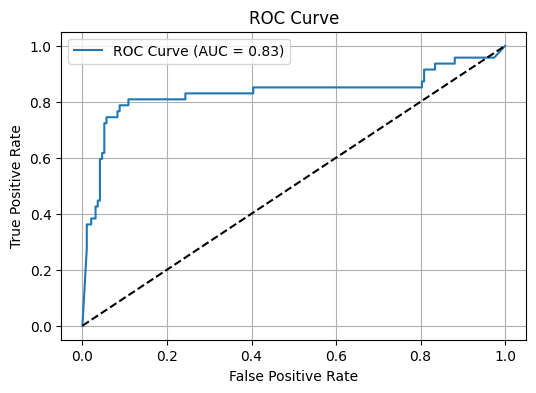

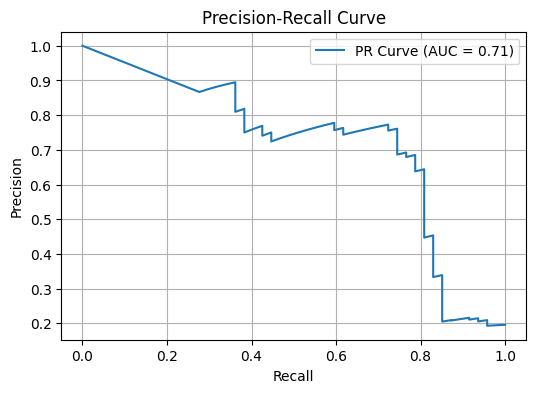

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def month_birth(ga):
    if ga <= 35:
        return '6ος-8ος μήνας'
    elif ga <= 40:
        return '9ος μήνας'
    else:
        return '10ος μήνας'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης month_birth σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'month_birth'
df_clean['month_birth'] = df_clean['GA'].apply(month_birth)

X = df_clean.drop(columns=['GA', 'month_birth', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, month_birth, Preterm_birth
y = df_clean['month_birth'] # Η μεταβλητή στόχος (month_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# 10-Fold Cross-Validation για internal validation
nb = GaussianNB()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(nb, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
nb.fit(X_train_balanced, y_train_balanced)
y_pred = nb.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ACCURACY: 0.5498
PRECISION_MACRO: 0.6610
RECALL_MACRO: 0.5496
F1_MACRO: 0.4930

Confusion Matrix:
 [[ 35   0   2]
 [ 10  22   7]
 [141   8  15]]

Classification Report:
                precision    recall  f1-score   support

   10ος μήνας       0.19      0.95      0.31        37
6ος-8ος μήνας       0.73      0.56      0.64        39
    9ος μήνας       0.62      0.09      0.16       164

     accuracy                           0.30       240
    macro avg       0.52      0.53      0.37       240
 weighted avg       0.58      0.30      0.26       240



In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def month_birth(ga):
    if ga <= 35:
        return '6ος-8ος μήνας'
    elif ga <= 40:
        return '9ος μήνας'
    else:
        return '10ος μήνας'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης month_birth σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'month_birth'
df_clean['month_birth'] = df_clean['GA'].apply(month_birth)

X = df_clean.drop(columns=['GA', 'month_birth', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, month_birth, Preterm_birth
y = df_clean['month_birth'] # Η μεταβλητή στόχος (month_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'var_smoothing': [1e-9, 1e-8, 1e-7]: τεχνική σταθεροποίησης για την αποφυγή αριθμητικών σφαλμάτων κατά τον υπολογισμό των πιθανοτήτων
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring='recall_macro',
    cv=10,
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train_balanced, y_train_balanced)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_model = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_model.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 10 folds for each of 3 candidates, totalling 30 fits
Best Parameters: {'var_smoothing': 1e-07}

Confusion Matrix:
 [[28  0  9]
 [ 0 27 12]
 [95 10 59]]

Classification Report:
                precision    recall  f1-score   support

   10ος μήνας       0.23      0.76      0.35        37
6ος-8ος μήνας       0.73      0.69      0.71        39
    9ος μήνας       0.74      0.36      0.48       164

     accuracy                           0.47       240
    macro avg       0.56      0.60      0.51       240
 weighted avg       0.66      0.47      0.50       240



In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def ga_bin_2weeks(ga):
    # Στρογγυλοποίηση προς τα κάτω και μετατροπή σε integer
    week = int(np.floor(ga))

    if 25 <= week <= 30:
        return '25-30'
    elif 31 <= week <= 32:
        return '31-32'
    elif 33 <= week <= 34:
        return '33-34'
    elif 35 <= week <= 36:
        return '35-36'
    elif 37 <= week <= 38:
        return '37-38'
    elif 39 <= week <= 40:
        return '39-40'
    elif 41 <= week <= 42:
        return '41-42'
    else:
        return 'εκτός ορίων'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης ga_bin σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'ga_bin'
df_clean['ga_bin'] = df_clean['GA'].apply(ga_bin_2weeks)

X = df_clean.drop(columns=['GA', 'ga_bin', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, ga_bin, Preterm_birth
y = df_clean['ga_bin'] # Η μεταβλητή στόχος (ga_bin)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# 10-Fold Cross-Validation για internal validation
nb = GaussianNB()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(nb, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
nb.fit(X_train_balanced, y_train_balanced)
y_pred = nb.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ACCURACY: 0.5868
PRECISION_MACRO: 0.6255
RECALL_MACRO: 0.5868
F1_MACRO: 0.5310

Confusion Matrix:
 [[ 2  0  0  1  0  0  0]
 [ 6  5  2  8  1  2  0]
 [ 4  1  2  4  0  0  0]
 [ 1  0  1  6  1  0  0]
 [15  1  4 30  2  7 15]
 [ 8  0  2 65  3 18 19]
 [ 0  0  0  0  0  0  4]]

Classification Report:
               precision    recall  f1-score   support

       25-30       0.06      0.67      0.10         3
       31-32       0.71      0.21      0.32        24
       33-34       0.18      0.18      0.18        11
       35-36       0.05      0.67      0.10         9
       37-38       0.29      0.03      0.05        74
       39-40       0.67      0.16      0.25       115
       41-42       0.11      1.00      0.19         4

    accuracy                           0.16       240
   macro avg       0.29      0.42      0.17       240
weighted avg       0.49      0.16      0.19       240



In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def ga_bin_2weeks(ga):
    # Στρογγυλοποίηση προς τα κάτω και μετατροπή σε integer
    week = int(np.floor(ga))

    if 25 <= week <= 30:
        return '25-30'
    elif 31 <= week <= 32:
        return '31-32'
    elif 33 <= week <= 34:
        return '33-34'
    elif 35 <= week <= 36:
        return '35-36'
    elif 37 <= week <= 38:
        return '37-38'
    elif 39 <= week <= 40:
        return '39-40'
    elif 41 <= week <= 42:
        return '41-42'
    else:
        return 'εκτός ορίων'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης ga_bin σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'ga_bin'
df_clean['ga_bin'] = df_clean['GA'].apply(ga_bin_2weeks)

X = df_clean.drop(columns=['GA', 'ga_bin', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, ga_bin, Preterm_birth
y = df_clean['ga_bin'] # Η μεταβλητή στόχος (ga_bin)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'var_smoothing': [1e-9, 1e-8, 1e-7]: τεχνική σταθεροποίησης για την αποφυγή αριθμητικών σφαλμάτων κατά τον υπολογισμό των πιθανοτήτων
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring='recall_macro',
    cv=10,
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train_balanced, y_train_balanced)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_model = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_model.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 10 folds for each of 3 candidates, totalling 30 fits
Best Parameters: {'var_smoothing': 1e-07}

Confusion Matrix:
 [[ 2  0  0  1  0  0  0]
 [ 0 11  2  6  3  2  0]
 [ 2  3  2  4  0  0  0]
 [ 0  2  2  3  2  0  0]
 [ 0  1  2  6 23 28 14]
 [ 0  0  0  3 10 82 20]
 [ 0  0  0  0  1  0  3]]

Classification Report:
               precision    recall  f1-score   support

       25-30       0.50      0.67      0.57         3
       31-32       0.65      0.46      0.54        24
       33-34       0.25      0.18      0.21        11
       35-36       0.13      0.33      0.19         9
       37-38       0.59      0.31      0.41        74
       39-40       0.73      0.71      0.72       115
       41-42       0.08      0.75      0.15         4

    accuracy                           0.53       240
   macro avg       0.42      0.49      0.40       240
weighted avg       0.62      0.53      0.55       240



In [1]:
import pandas as pd
import zipfile
import os

# Διαδρομή αρχείου
file_path = '/content/Pre-term-labour-Data-ready-for-ml-pipeline_final.xlsx'

# Φόρτωση δεδομένων
df = pd.read_excel(file_path)

# Προβολή δεδομένων
df.head()

,Maternal age,GA,BW centile,UtA doppler,b-hcg,DVP,MCA doppler,Papp-A,Height,UA doppler,...,Placental location_high posterior with anterior paraplacenta,Placental location_high right,Placental location_ligh anterior with posterior paraplacenta,Placental location_low anterior,Placental location_low posterior,Placental location_low posterior with anterior paraplacenta,Placental location_low right,Placental location_previa,Single umbilical artery_0,Single umbilical artery_1
0,32.000000,24.285714,20.378457,1.010,0.98,5.1,2.03,0.90,166.0,1.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,33.000000,25.285714,16.129898,0.880,0.95,4.0,2.10,1.12,165.0,0.91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,36.435616,32.571429,74.037300,0.675,1.30,3.6,1.87,0.50,175.0,0.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,42.000000,28.714286,71.680853,1.350,1.00,1.4,1.87,0.90,160.0,1.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,33.000000,29.285714,22.836726,0.640,1.13,4.1,2.02,1.12,163.0,1.08,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [2]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
import numpy as np

# Καθαρισμός δεδομένων
df['Preterm_birth'] = pd.to_numeric(df['Preterm_birth'], errors='coerce')
df_clean = df.dropna(subset=['Preterm_birth']).copy() # Αφαίρεση των γραμμών με τιμή NaN
df_clean = df_clean.drop(columns=['GA']) # Αφαίρεση γιατί επηρεάζει σημαντικά την πρόβλεψη
df_clean['Preterm_birth'] = df_clean['Preterm_birth'].astype(int)

X = df_clean.drop(columns=['Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός της Preterm_birth
y = df_clean['Preterm_birth'] # Η μεταβλητή στόχος (Preterm_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# 10-Fold Cross-Validation για internal validation
nb = GaussianNB()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(nb, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
nb.fit(X_train_balanced, y_train_balanced)
y_pred = nb.predict(X_test) # Προβλέψεις ανά κατηγορία ('0' ή '1')
y_proba = nb.predict_proba(X_test)[:, 1] # Πιθανότητες για την κατηγορία '1' (πρόωρος τοκετός)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))
print("\nPR AUC Score:", average_precision_score(y_test, y_proba))

ACCURACY: 0.7063
PRECISION: 0.9610
RECALL: 0.4325
F1: 0.5927
ROC_AUC: 0.8876
AVERAGE_PRECISION: 0.8988

Confusion Matrix:
 [[191   2]
 [ 69  29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.99      0.84       193
           1       0.94      0.30      0.45        98

    accuracy                           0.76       291
   macro avg       0.84      0.64      0.65       291
weighted avg       0.80      0.76      0.71       291


ROC AUC Score: 0.9199534736174262

PR AUC Score: 0.8684804307874382
